# **Hospital Readmission Rates - Data Visualisation and EDA**

## Objectives

* Import dataset from "Clean Data" file
* Determine conclusions from visualisations of data
* Perform Statistical Analyses of data where possible
* Challenge Hypotheses via conclusions

## Inputs

* Dataset from the "Clean Data" CSV file, imported from the "Clean Data" folder

## Outputs

* Statistical Analysis of dataset
* Visualisations created from Clean dataset
* Conclusions based off of data visualisation and EDA (Exploratory Data Analysis)



---

# Hypotheses

The Dataset contains medical records of hospital encounters for diabetes patients from 130 US hospitals between the period of 1999-2008. Each record denotes a visit to the hospital by the patient.It also then documents whether the patient was readmitted after that visit or not and if they were then was it after 30 days or before this. The hypotheses determined relate to this data.  Diabetes patient's readmittance to hospital puts a large economic and social strain on hospitals so being able to identify the factors that impact this the most is very important.

The business requirement is as follows:

* Identify what factors will increase the likelihood of diabetes patient readmittance to hospital.


The hypotheses for the dataset are as follows: 

1) Age: 
    * H<sub>0</sub>: Age has no impact on diabetes patient readmittance rates to hospital.
2) Race:
    * H<sub>0</sub>: Race has no impact on diabetes patient readmittance rates to hospital.
3) Gender:
    * H<sub>0</sub>: Gender has no impact on diabetes patient readmittance rates to hospital.
4) Time in hospital:
    * H<sub>0</sub>: Time spent in hospital during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
5) Number of medications:
    * H<sub>0</sub>: Number of medications administered during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
6) Number of Lab procedures:
    * H<sub>0</sub>: Number of lab procedures performed during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
7) Number of Non-lab procedures:
    * H<sub>0</sub>: Number of non-lab procedures performedduring a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
8) Prior Visit History:
    * H<sub>0</sub>: The type of prior visits a patient does (Inpatient, Outpatient, Emergency) over the last year, has no impact on diabetes patient readmittance rates to hospital.
9) Diagnosis type:
    * H<sub>0</sub>: The type of diagnoses during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
10) Medicinal Changes:
    * H<sub>0</sub>: Any Medicinal changes during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
11) Testing performed:
    * H<sub>0</sub>: Blood testing performed during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\hospital_readmission_rates_analysis\\hospital_readmission_rates_analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\hospital_readmission_rates_analysis\\hospital_readmission_rates_analysis'

---

# Import required packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import scipy
from scipy.stats import ttest_ind

---

# Import Clean Dataset

The clean dataset must be imported as a new dataframe for use in visualisations.

In [5]:
clean_hospital_data_df = pd.read_csv("data_files/CleanData/clean_hospital_data.csv")
clean_hospital_data_df

,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),1,41,0,1,0,0,0,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),3,59,0,18,0,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),2,44,1,16,0,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,51,0,8,0,0,0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99467,AfricanAmerican,Male,[70-80),3,51,0,16,0,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,>30
99468,AfricanAmerican,Female,[80-90),5,33,3,18,0,0,1,...,No,Steady,No,No,No,No,No,No,Yes,NO
99469,Caucasian,Male,[70-80),1,53,0,9,1,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,NO
99470,Caucasian,Female,[80-90),10,45,2,21,0,0,1,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [6]:
clean_hospital_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99472 entries, 0 to 99471
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      99472 non-null  object
 1   gender                    99472 non-null  object
 2   age                       99472 non-null  object
 3   time_in_hospital          99472 non-null  int64 
 4   num_lab_procedures        99472 non-null  int64 
 5   num_procedures            99472 non-null  int64 
 6   num_medications           99472 non-null  int64 
 7   number_outpatient         99472 non-null  int64 
 8   number_emergency          99472 non-null  int64 
 9   number_inpatient          99472 non-null  int64 
 10  diag_1                    99472 non-null  object
 11  diag_2                    99472 non-null  object
 12  diag_3                    99472 non-null  object
 13  max_glu_serum             99472 non-null  object
 14  A1Cresult             

---

# Visualisations

The visualisations for the data will be split between numerical and categoric data for cleaner EDA.

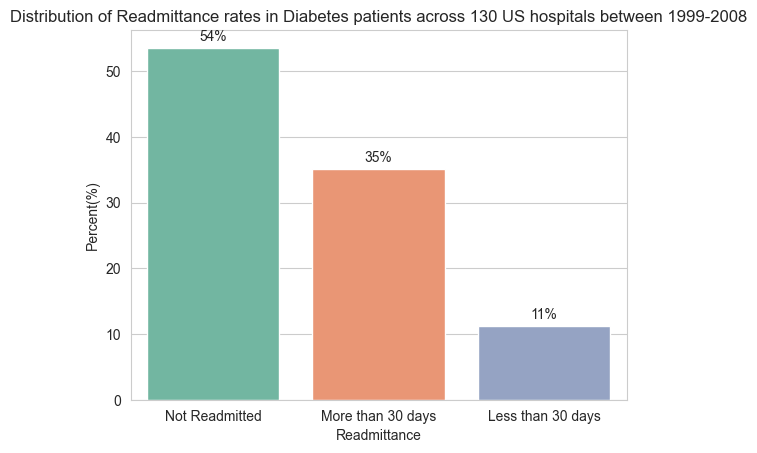

In [7]:
readmittance_percentage_plot = sns.countplot (data = clean_hospital_data_df, x="readmitted", order= clean_hospital_data_df["readmitted"].value_counts().index, hue= "readmitted", palette ="Set2", stat = "percent" )

for container in readmittance_percentage_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    readmittance_percentage_plot.bar_label(container, labels=labels, padding= 3)


plt.title("Distribution of Readmittance rates in Diabetes patients across 130 US hospitals between 1999-2008")
plt.xlabel("Readmittance")
plt.xticks( ticks = [0,1,2], labels=["Not Readmitted", "More than 30 days","Less than 30 days"])
plt.ylabel("Percent(%)")
plt.show()


An initial analysis shows that, in this dataset, only 54% of the patients were not readmitted to hospital. Of the remaining 46%, 11% were readmitted in less than 30 days and 35% were readmitted in more than 30 days since discharge. Further EDA will reveal which patients were more likely to be readmitted

## _Numerical Data_

The numerical data held in this dataset are the following fields:

* Time spent in hospital  - Number of days between admission and discharge
* Number of Lab procedures -  Procedures during the encounter
* Number of non-lab procedures - Procedures  during the encounter
* Number of medications - Medications administered during the encounter
* Number of Outpatient visits - Logged for the year preceding the encounter
* Number of Emergency visits - Logged for the year preceding the encounter
* Number of Inpatient visits - Logged for the year preceding the encounter



Initiall, a short statistical summary of each field will be run.

In [8]:
clean_hospital_data_df[["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications","number_outpatient","number_emergency","number_inpatient"]].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient
count,99472.000000,99472.000000,99472.000000,99472.000000,99472.000000,99472.000000,99472.000000
mean,4.398524,43.074433,1.340679,16.026832,0.373392,0.201333,0.643055
std,2.987179,19.695127,1.703786,8.120211,1.276910,0.940045,1.271399
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000


We will do a correlation heatmap to see if there is any correlation across all numeric columns and readmittance rates in patients.

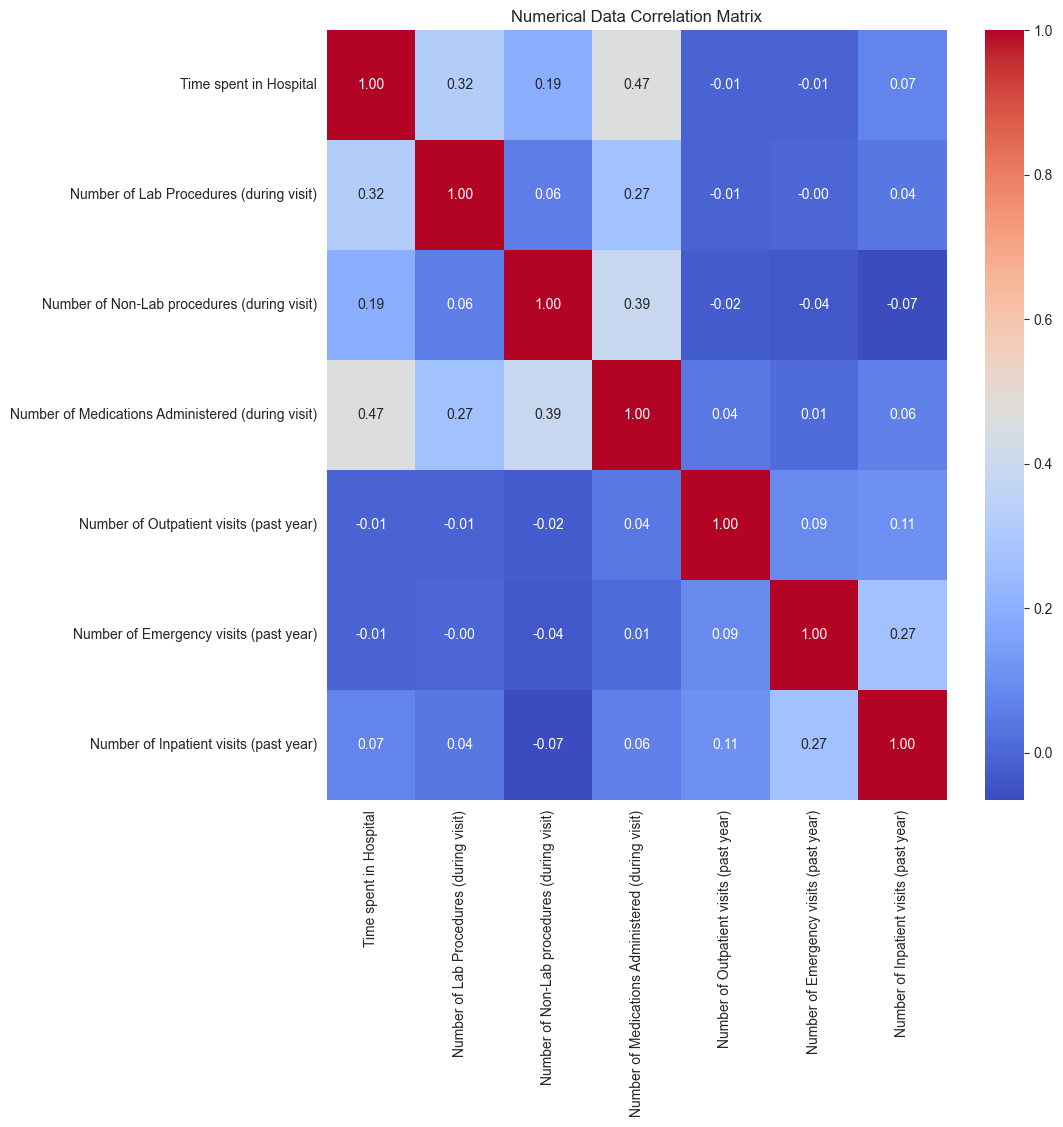

In [9]:
plt.figure(figsize=(10,10))
correlation_matrix_numeric = clean_hospital_data_df[["time_in_hospital", "num_lab_procedures", "num_procedures", 
                                                     "num_medications","number_outpatient","number_emergency","number_inpatient"]].corr()
correlation_matrix_numeric_labels = ["Time spent in Hospital", "Number of Lab Procedures (during visit)", 
                                     "Number of Non-Lab procedures (during visit)", "Number of Medications Administered (during visit)",
                                     "Number of Outpatient visits (past year)","Number of Emergency visits (past year)","Number of Inpatient visits (past year)"]

sns.heatmap(
    correlation_matrix_numeric,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    xticklabels=correlation_matrix_numeric_labels,
    yticklabels= correlation_matrix_numeric_labels
)
plt.title("Numerical Data Correlation Matrix")
plt.show()

From this matrix, we are able to determine the following relationships:

* Time spent in hospital has the strongest correlation of all the variables with number of medications administered. This could be for the following reason:
    * The longer a patient spent in hospital, the more medications were required for treatment.
* Number of lab procedures during the encounter is slightly correlative with medications administered however, number of non-lab procedures is more correlative with the number of medications administered.  This could be for the following reason:
    * Non-lab procedures require the use of medications more than lab procedures do.
* The type of patient visits in the year previous to admittance had slight correlations to the time spent in hospital:
    * The number of inpatient visits from the year previous to the hospital admittance is slightly correlative to the time the patient would spend in hospital.
    * The number of emergency and outpatient visits from the year previous to the hospital admittance is slightly negatively correlative to the time the patient would spend in hospital.
        * This could be because:
            * Inpatient visits may be linked to more chronic illness which means that the time required to treat it is longer in hospital.
* The type of patient visits also have relationships with eachother:
    * The more outpatient visits a patient had, the more likely they were to have inpatient visits.
    * The more emergency visits a patient had, the more likely there were to have inpatient visits.

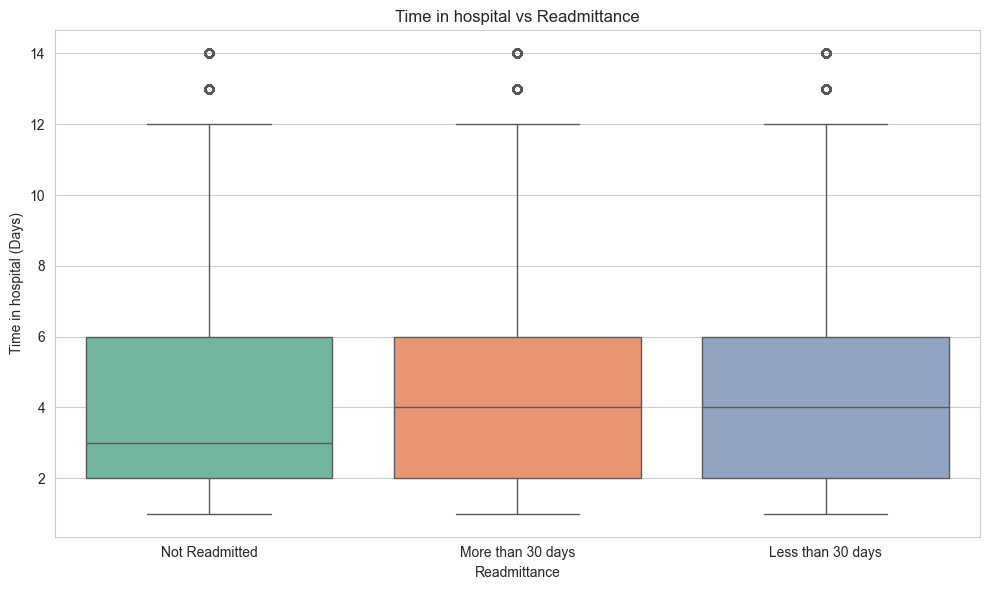

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data= clean_hospital_data_df,
    x="readmitted",
    y="time_in_hospital",
    hue="readmitted",   
    palette="Set2",
    ax=ax
)

ax.set_title("Time in hospital vs Readmittance")
ax.set_xlabel("Readmittance")
ax.set_xticks( ticks = [0,1,2], labels=["Not Readmitted", "More than 30 days","Less than 30 days"])
ax.set_ylabel("Time in hospital (Days)")
 

plt.tight_layout()
plt.show()

From the above plot, we can see:

* Patients that were readmitted, spent more time in hospital during their initial encounters than those who were not.
* The mean values for readmittance is around 4 days while for no readmittance is 3 days.
* There are some outliers in the data that may skew the data but the outliers are the same across the data and so the data can still be trusted as there is consistency.

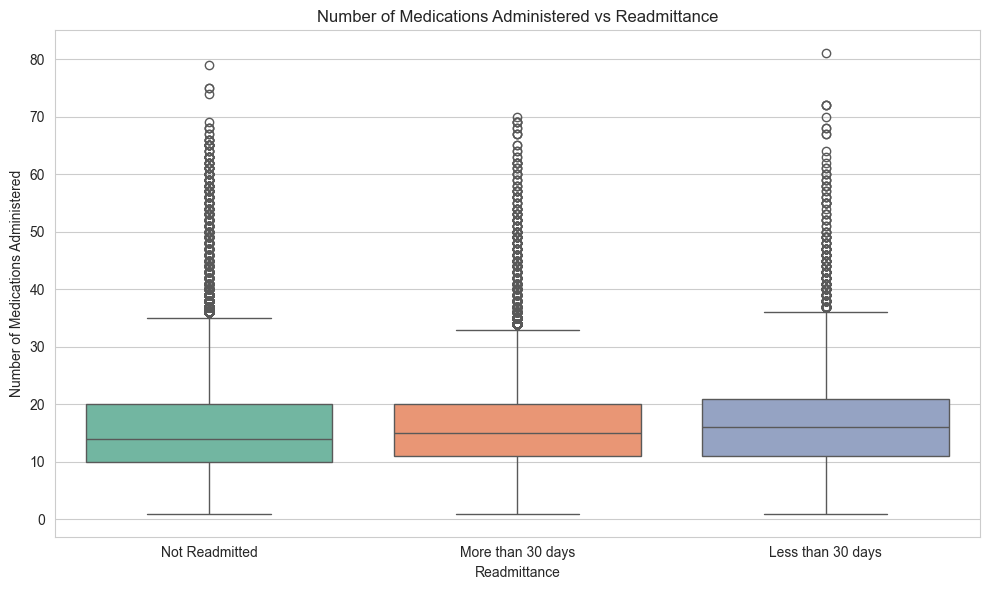

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data= clean_hospital_data_df,
    x="readmitted",
    y="num_medications",
    hue="readmitted",   
    palette="Set2",
    ax=ax
)

ax.set_title("Number of Medications Administered vs Readmittance")
ax.set_xlabel("Readmittance")
ax.set_xticks( ticks = [0,1,2], labels=["Not Readmitted", "More than 30 days","Less than 30 days"])
ax.set_ylabel("Number of Medications Administered")
 

plt.tight_layout()
plt.show()

From the above plot we can see:

* There is a slight higher mean for number of medicines administered in patients who were readmitted over those who weren't.
* There are lots of outliers in this data which is causing a positive skew in the data. This means that a lot of people were administered more medicines than the average.

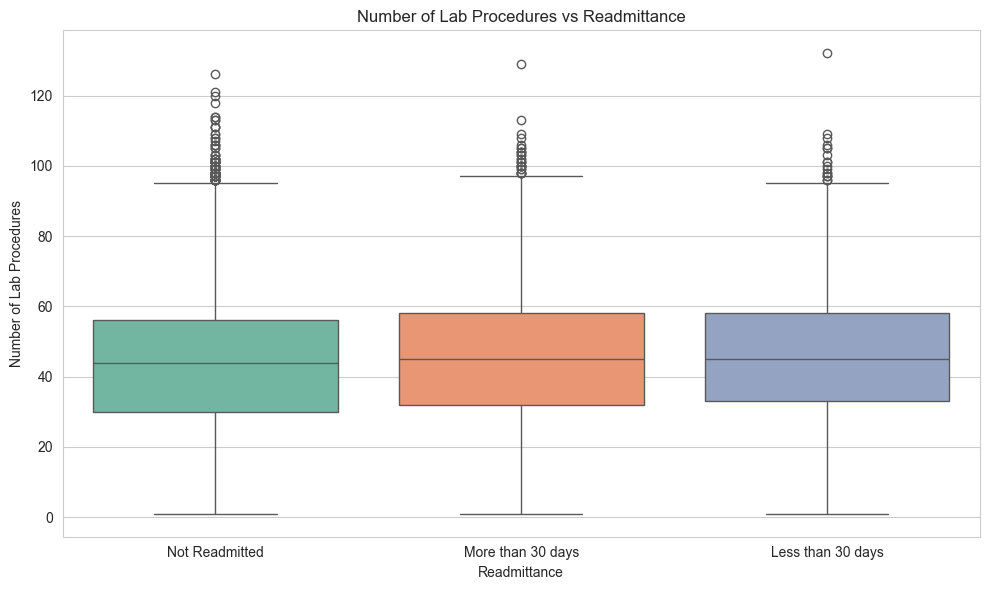

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data= clean_hospital_data_df,
    x="readmitted",
    y="num_lab_procedures",
    hue="readmitted",   
    palette="Set2",
    ax=ax
)

ax.set_title("Number of Lab Procedures vs Readmittance")
ax.set_xlabel("Readmittance")
ax.set_xticks( ticks = [0,1,2], labels=["Not Readmitted", "More than 30 days","Less than 30 days"])
ax.set_ylabel("Number of Lab Procedures")
 

plt.tight_layout()
plt.show()

From the above plot we can see:

* There is no significant difference in the mean for number of lab procedures in patients who were readmitted over those who weren't.
* There are lots of outliers in this data which is causing a positive skew in the data. This means that a lot of people underwent more lab procedures than the average.

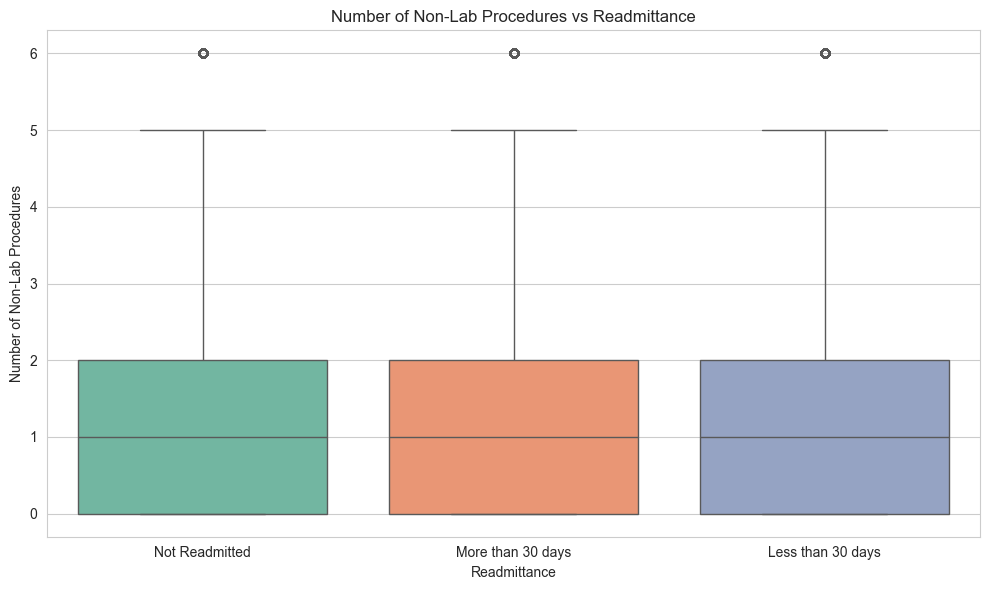

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data= clean_hospital_data_df,
    x="readmitted",
    y="num_procedures",
    hue="readmitted",   
    palette="Set2",
    ax=ax
)

ax.set_title("Number of Non-Lab Procedures vs Readmittance")
ax.set_xlabel("Readmittance")
ax.set_xticks( ticks = [0,1,2], labels=["Not Readmitted", "More than 30 days","Less than 30 days"])
ax.set_ylabel("Number of Non-Lab Procedures")
 

plt.tight_layout()
plt.show()

From the above plot we can see:

* There is no siginificant difference in the means for number of non-lab procedures in patients who were readmitted over those who weren't.
* There is only one single outlier value for all three categories. This means that the data isn't too skewed.

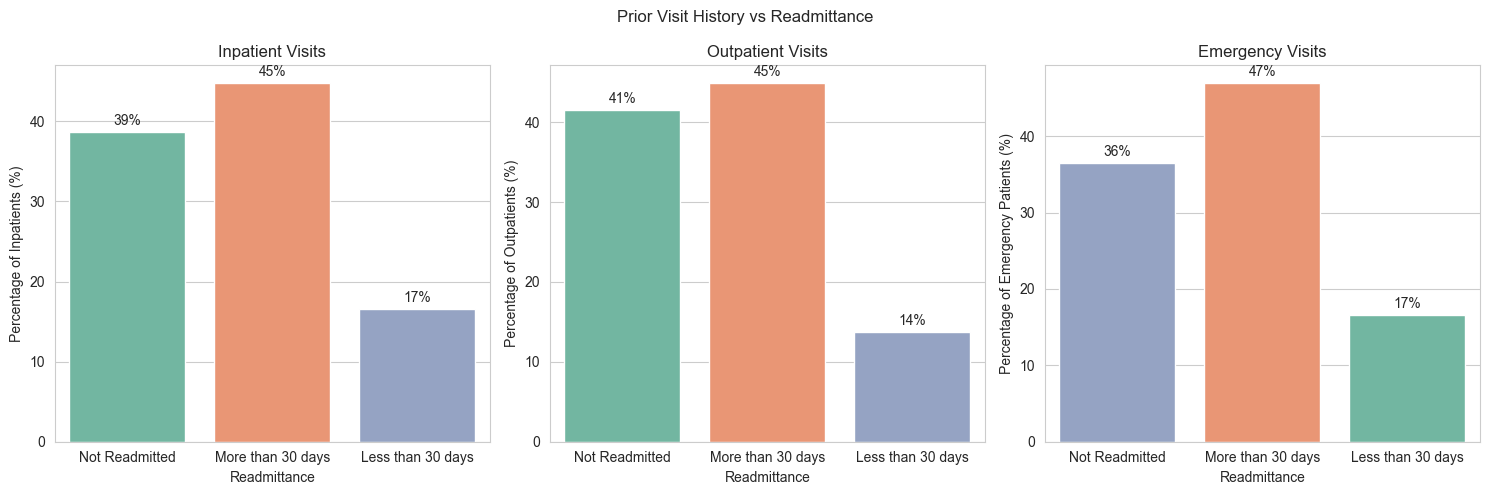

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

inpatient_readmittance_plot = sns.countplot(data=clean_hospital_data_df[clean_hospital_data_df["number_inpatient"]>0], x="readmitted", order= clean_hospital_data_df["readmitted"].value_counts().index, ax=axes[0], hue= "readmitted", palette = "Set2", stat = "percent")

for container in inpatient_readmittance_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    inpatient_readmittance_plot.bar_label(container, labels=labels, padding= 3)

axes[0].set_title("Inpatient Visits")
axes[0].set_xticks( ticks = [0,1,2], labels=["Not Readmitted", "More than 30 days","Less than 30 days"])
axes[0].set_xlabel("Readmittance")
axes[0].set_ylabel("Percentage of Inpatients (%)")


outpatient_readmittance_plot = sns.countplot(data=clean_hospital_data_df[clean_hospital_data_df["number_outpatient"]>0], x="readmitted", order= clean_hospital_data_df["readmitted"].value_counts().index, ax=axes[1], hue= "readmitted", palette = "Set2", stat = "percent")

for container in outpatient_readmittance_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    outpatient_readmittance_plot.bar_label(container, labels=labels, padding= 3)

axes[1].set_title("Outpatient Visits")
axes[1].set_xticks( ticks = [0,1,2], labels=["Not Readmitted", "More than 30 days","Less than 30 days"])
axes[1].set_xlabel("Readmittance")
axes[1].set_ylabel("Percentage of Outpatients (%)")


emergency_readmittance_plot = sns.countplot(data=clean_hospital_data_df[clean_hospital_data_df["number_emergency"]>0], x="readmitted", order= clean_hospital_data_df["readmitted"].value_counts().index, ax=axes[2], hue= "readmitted", palette = "Set2", stat = "percent")

for container in emergency_readmittance_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    emergency_readmittance_plot.bar_label(container, labels=labels, padding= 3)

axes[2].set_title("Emergency Visits")
axes[2].set_xticks( ticks = [0,1,2], labels=["Not Readmitted", "More than 30 days","Less than 30 days"])
axes[2].set_xlabel("Readmittance")
axes[2].set_ylabel("Percentage of Emergency Patients (%)")

plt.suptitle("Prior Visit History vs Readmittance")
plt.tight_layout()
plt.show()

Prior history was data captured for the year prior to the hospital encounter. The type of visit was documented.

From the above plots we can determine:

* Patients who had Emergency visits had a 64% readmittance rate while patients who had Inpatient visits had a 62% readmittance rate as compared to Outpatient visits which had a 59% readmittance rate.
* Outpatient visit patients had the lowest readmittance within 30 days at 14%
* Emergency visit patients had the highest readmittance rate outside of 30 days at 47%
* In order of most to least patients not readmitted:
    * Outpatient
    * Inpatient
    * Emergency

Conclusively, it seems that patients who encountered Emergency visits were most likely to be readmitted to hospital.

 ## _Categorical Data_


The categorical data to be explored is as follows:

* Age
* Race
* Gender
* Diagnosis
* Changes to Diabetic Medication (in documented hospital encounter)
* Prescription of Diabetic Medication (in documented hospital encounter)
* Details of Medication (documented changes or non-changes to prescribed diabetes medication during hospital encounter)
* Blood sugar testing

In [33]:
age_pivot = clean_hospital_data_df.pivot_table( index= "readmitted", columns = "age", values = "time_in_hospital", aggfunc= "mean")

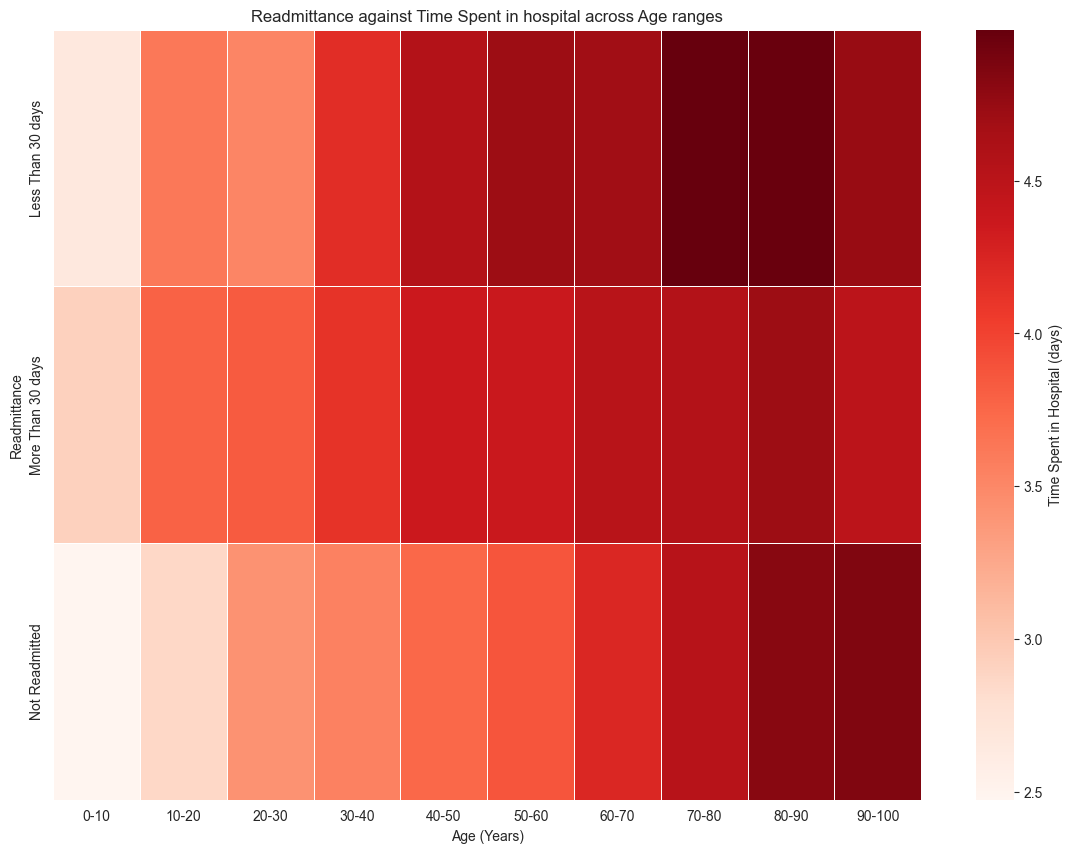

In [16]:
plt.figure(figsize=(14,10))

sns.heatmap(age_pivot,cmap= "Reds", linewidths= 0.5, cbar_kws={"label":"Time Spent in Hospital (days)"})

plt.title("Readmittance against Time Spent in hospital across Age ranges")
plt.xlabel("Age (Years)")
plt.xticks( ticks =[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5], labels=["0-10","10-20","20-30","30-40","40-50","50-60","60-70","70-80","80-90","90-100"] )
plt.ylabel("Readmittance")
plt.yticks(ticks = [0.5,1.5,2.5], labels=["Less Than 30 days","More Than 30 days", "Not Readmitted"])
plt.show()

From the above matrix, we can see:

* The older the patient, the more time they spent in hospital, regardless of readmittance status.
* Patients who were readmitted, tend to have spent more time in hospital than those who were not.



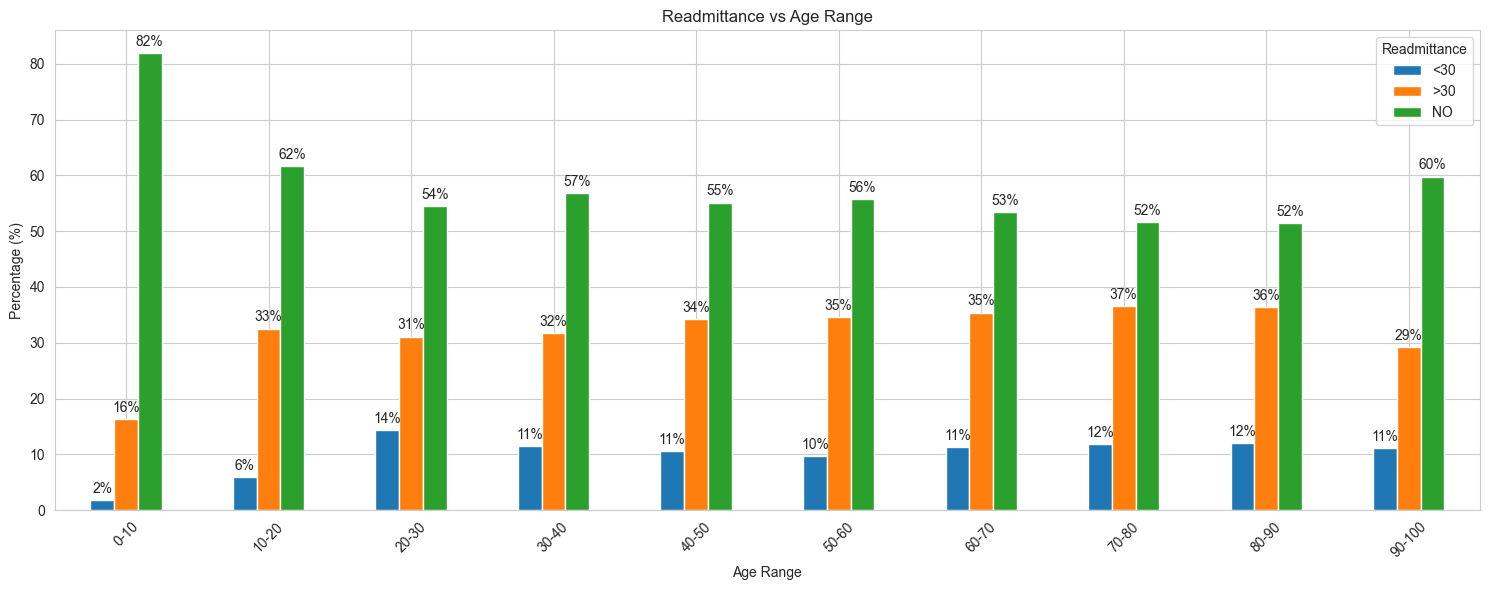

In [17]:
cross = pd.crosstab(clean_hospital_data_df["age"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(15, 6))

age_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in age_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    age_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs Age Range")
ax.set_xlabel("Age Range")
ax.set_xticks(ticks =[0,1,2,3,4,5,6,7,8,9], labels=["0-10","10-20","20-30","30-40","40-50","50-60","60-70","70-80","80-90","90-100"] )
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

Further analysis shows:

* The older the patient, the more likely they are to be readmitted. There is a general negative trend as age increases for Non-readmittance rates.
* The patients in the "0-10" age range have a readmittance rate of only 18% whereas, patients in older age ranges ,such as 70-80 and 80-90, have readmittance rates of 49% and 48% respectively.
* This is a massively significant difference and indicates that age has a strong effect on readmittance rates.

In [18]:
race_pivot = clean_hospital_data_df.pivot_table( index= "readmitted", columns = "race", values = "time_in_hospital", aggfunc= "mean")

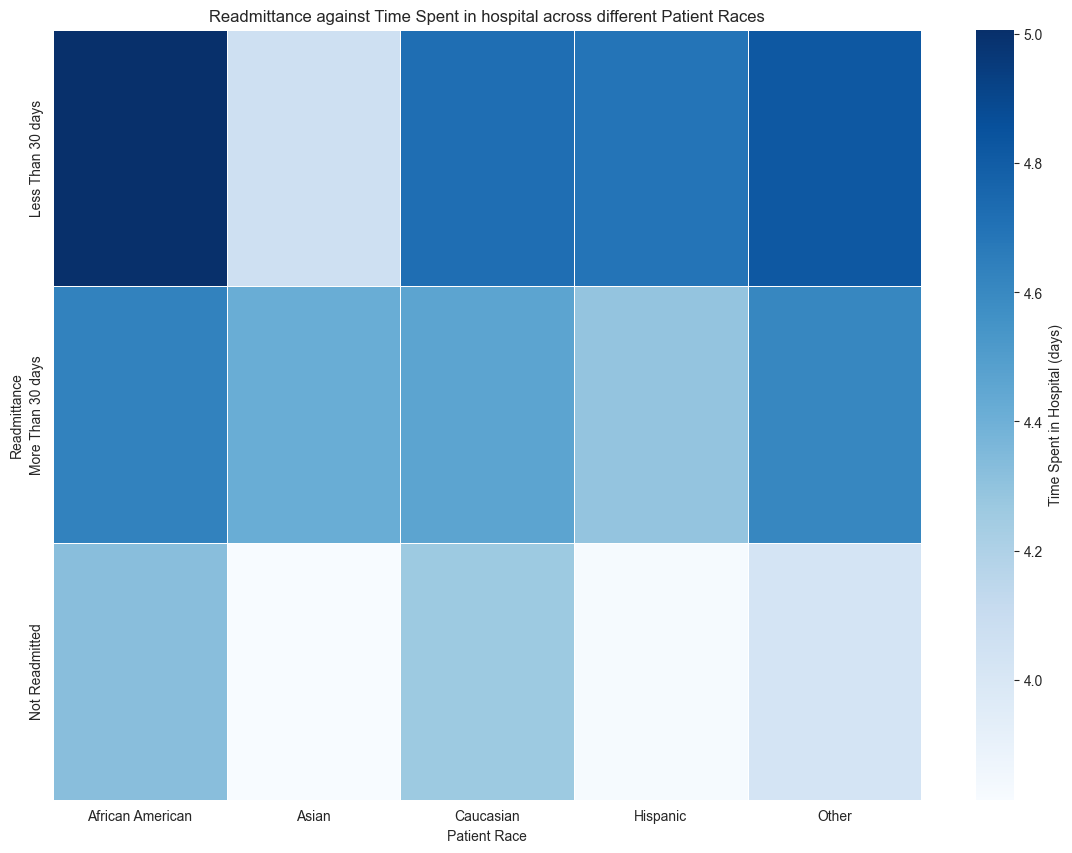

In [19]:
plt.figure(figsize=(14,10))

sns.heatmap(race_pivot,cmap= "Blues", linewidths= 0.5, cbar_kws={"label":"Time Spent in Hospital (days)"})

plt.title("Readmittance against Time Spent in hospital across different Patient Races")
plt.xlabel("Patient Race")
plt.xticks( ticks =[0.5,1.5,2.5,3.5,4.5], labels=["African American","Asian","Caucasian","Hispanic","Other"] )
plt.ylabel("Readmittance")
plt.yticks(ticks = [0.5,1.5,2.5], labels=["Less Than 30 days","More Than 30 days", "Not Readmitted"])
plt.show()

From the above matrix, we can see:

* African American patients had the most time spent in hospital of patients, especially in the "Less than 30 days" category.
* Asian and Hispanic patients spent little time in hospital and so were also not readmitted.
* Asian patients who were readmitted within 30 days also spent little time in hospital.
* The varying results show that there is potentially some discrepancy in the treatment recieved by patients of different races.


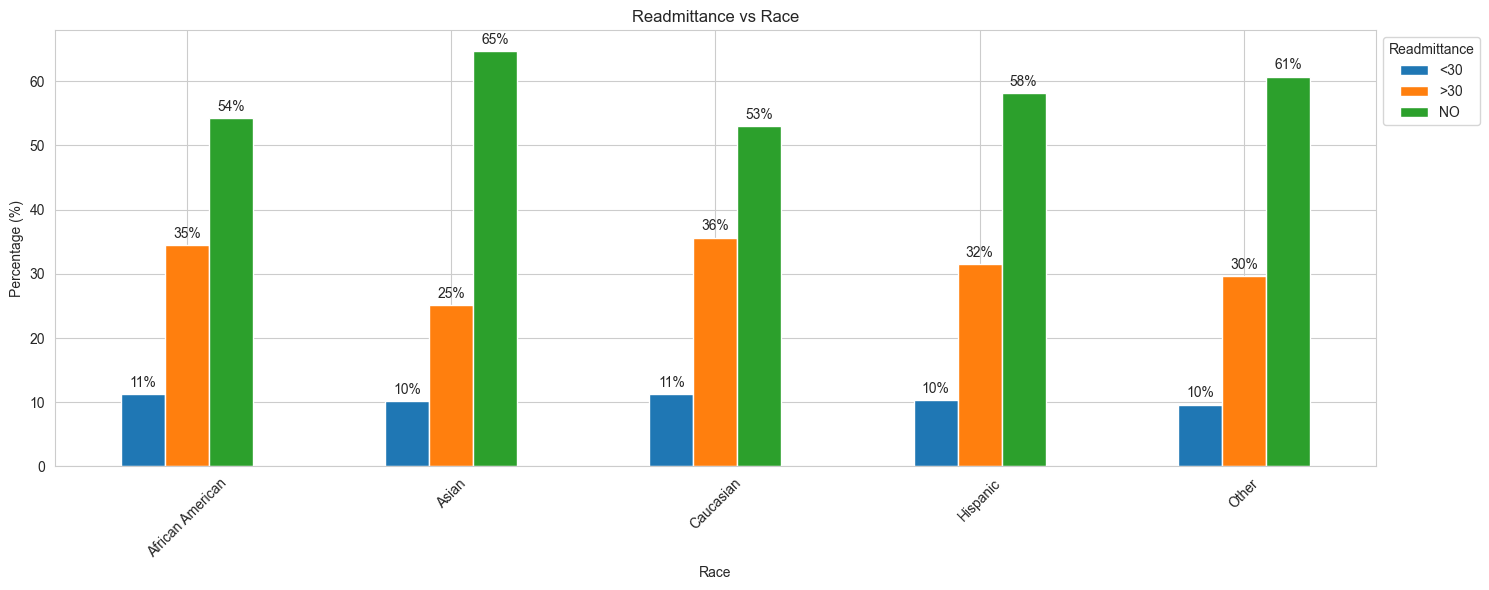

In [20]:
cross = pd.crosstab(clean_hospital_data_df["race"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(15, 6))

race_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in race_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    race_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs Race")
ax.set_xlabel("Race")
ax.set_xticks( ticks = [0,1,2,3,4], labels=["African American","Asian","Caucasian","Hispanic","Other"])
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

From the above plot, we can see:

* Asian patients were the least readmitted to hospital at 35%
* The most readmitted to hospital was actually Caucasian patients at 47%, while African American patients followed closely at 46%
* It can be seen that there is a difference in time spent at hospital data vs readmittance rates for races. This indicates that while some races have similar readmittance rates, they have differing lengths of time spent in hospital potentially as a result of care discrepancy.

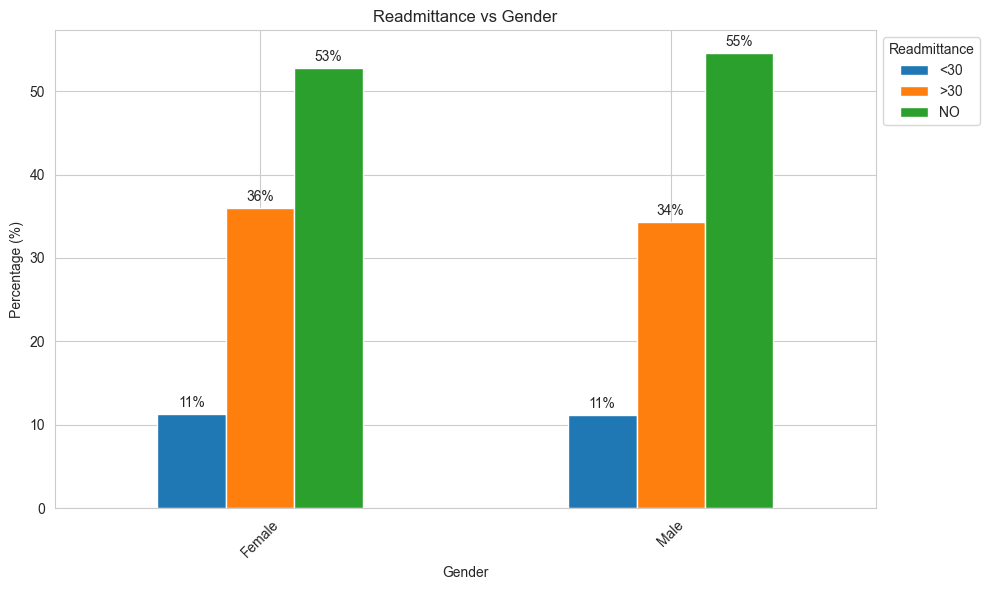

In [21]:
cross = pd.crosstab(clean_hospital_data_df["gender"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(10, 6))

gender_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in gender_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    gender_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

From the above plot, we can see:

* There is little to no significant difference in the readmittance rates for men and women as the rates are 47% & 45% respectively and so only slightly different.

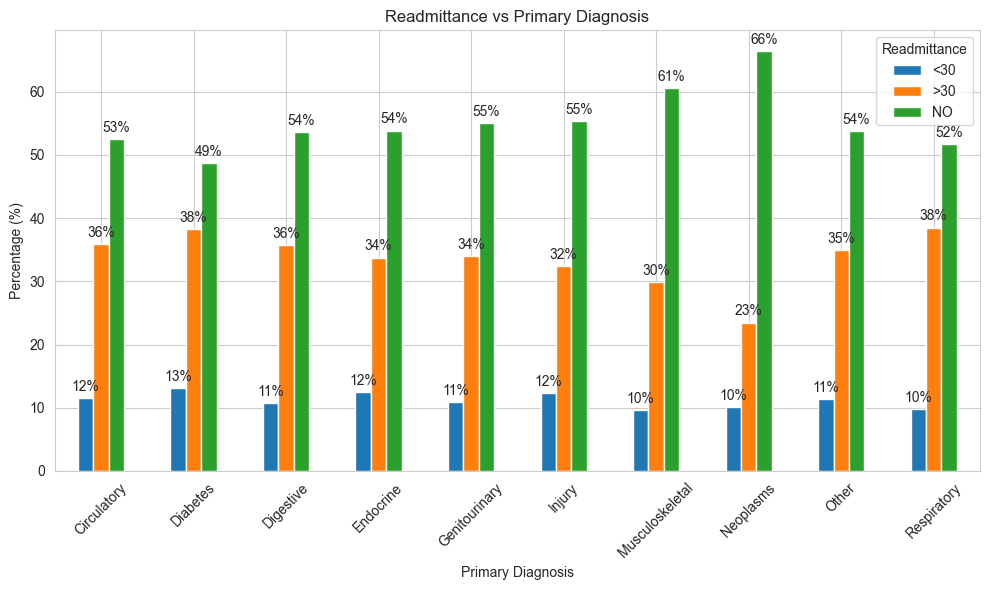

In [22]:
cross = pd.crosstab(clean_hospital_data_df["diag_1"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(10, 6))

primary_diagnosis_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in primary_diagnosis_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    primary_diagnosis_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs Primary Diagnosis")
ax.set_xlabel("Primary Diagnosis")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

From the above plot, we can see:

* Readmittance for each primary diagnosis for patients are as follows:
    * Circulatory - 48%
    * Diabetes - 52%
    * Digestive - 47%
    * Endocrine - 46%
    * Genitourinary - 45%
    * Injury - 44%
    * Musculoskeletal - 30%
    * Neoplasms - 33%
    * Other - 46%
    * Respiratory - 48%
* Diabetes patients had the highest readmittance rates as opposed to Musculoskeletal patients who had the least readmittance rates.

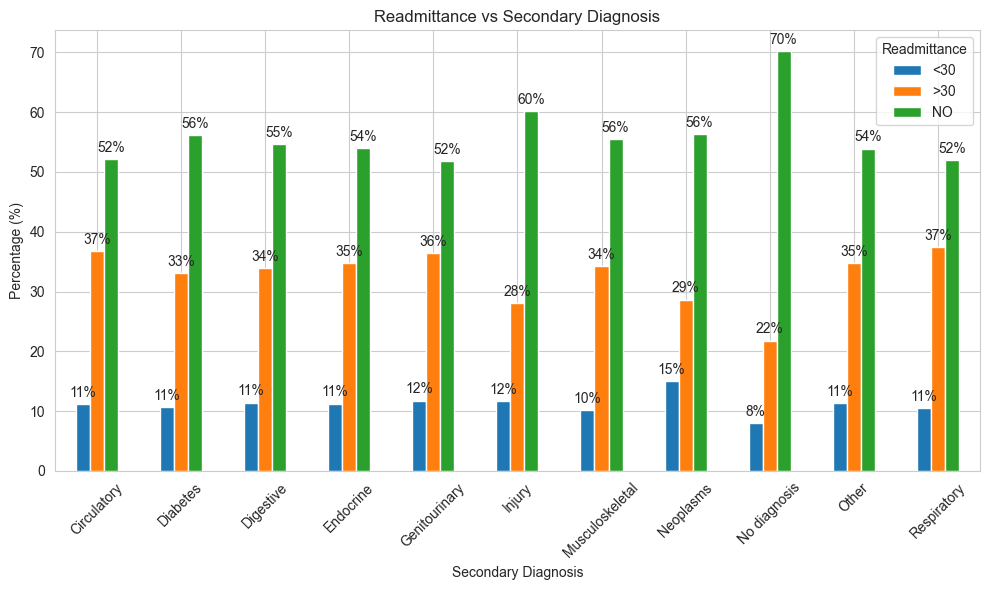

In [23]:
cross = pd.crosstab(clean_hospital_data_df["diag_2"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(10, 6))

secondary_diagnosis_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in secondary_diagnosis_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    secondary_diagnosis_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs Secondary Diagnosis")
ax.set_xlabel("Secondary Diagnosis")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

From the above plot, we can see:

* Readmittance for each secondary diagnosis for patients are as follows:
    * Circulatory - 48%
    * Diabetes - 44%
    * Digestive - 45%
    * Endocrine - 46%
    * Genitourinary - 48%
    * Injury - 40%
    * Musculoskeletal - 44%
    * Neoplasms - 44%
    * No diagnosis - 30%
    * Other - 46%
    * Respiratory - 48%
* This time, patients of the following categories had the highest readmittance rates:
    * Circulatory
    * Genitourinary
    * Respiratory    
* The least readmittance rates were found to be in patients with no secondary diagnosis. This could be due to the primary diagnosis being treated well and determined correctly.

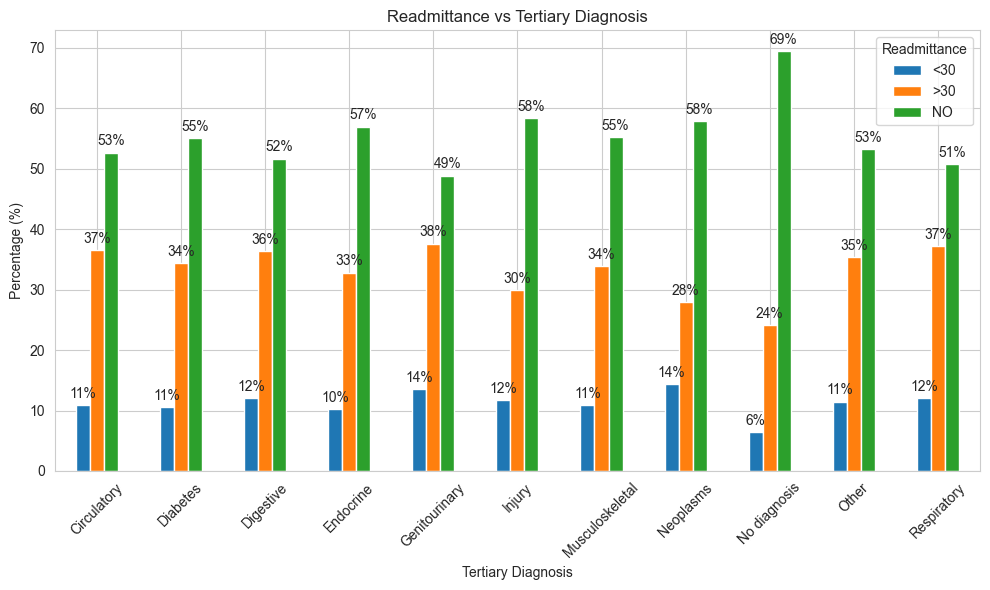

In [24]:
cross = pd.crosstab(clean_hospital_data_df["diag_3"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(10, 6))

tertiary_diagnosis_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in tertiary_diagnosis_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    tertiary_diagnosis_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs Tertiary Diagnosis")
ax.set_xlabel("Tertiary Diagnosis")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

From the above plot, we can see:

* Readmittance for each tertiary diagnosis for patients are as follows:
    * Circulatory - 48%
    * Diabetes - 45%
    * Digestive - 48%
    * Endocrine - 43%
    * Genitourinary - 52%
    * Injury - 42%
    * Musculoskeletal - 45%
    * Neoplasms - 42%
    * No diagnosis - 30%
    * Other - 46%
    * Respiratory - 49%
* This time, patients of the following categories had the highest readmittance rates:
    * Genitourinary    
* The least readmittance rates were found to be in patients with no tertiary diagnosis. Again, this could be due to the primary and secondary diagnoses being treated well and determined correctly.

A comparison across all three diagnosis columns tells us the following:

* As a primary diagnosis, Diabetes is most likely to have readmittance in patients whereas Musculoskeletal issues is not.
* When a secondary or tertiary diagnosis is required, Genitourinary disease patients are most likely to be readmitted. This can be due to not treating the correct illness or not determining the correct illness as the primary.
* Diabetes is also shown to increase the impact and likelihood of Genitourinary diseases so the potential poor treatment and maintenance of diabetes can be a major indicator as to why it has higher readmittance rates.

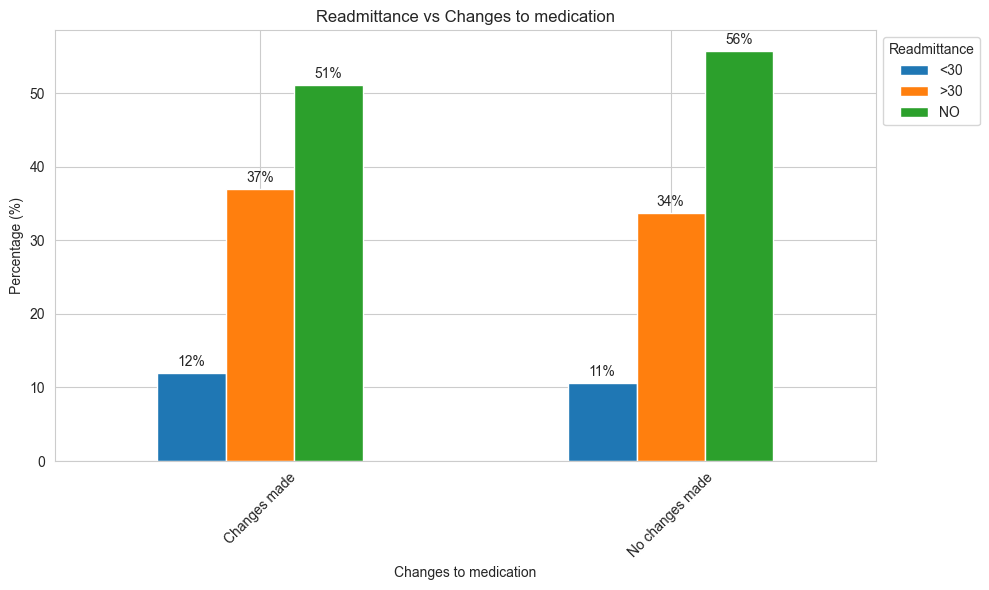

In [25]:
cross = pd.crosstab(clean_hospital_data_df["change"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(10, 6))

change_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in change_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    change_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs Changes to medication")
ax.set_xlabel("Changes to medication")
ax.set_xticks( ticks = [0,1], labels=["Changes made","No changes made"])
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

From the above plot, we can see:

* There is little to no significant difference in the readmittance rates for patients who had changes to their medication during their hospital encounter as opposed to not. This is because the rates are 48% & 45% respectively and so only slightly different.

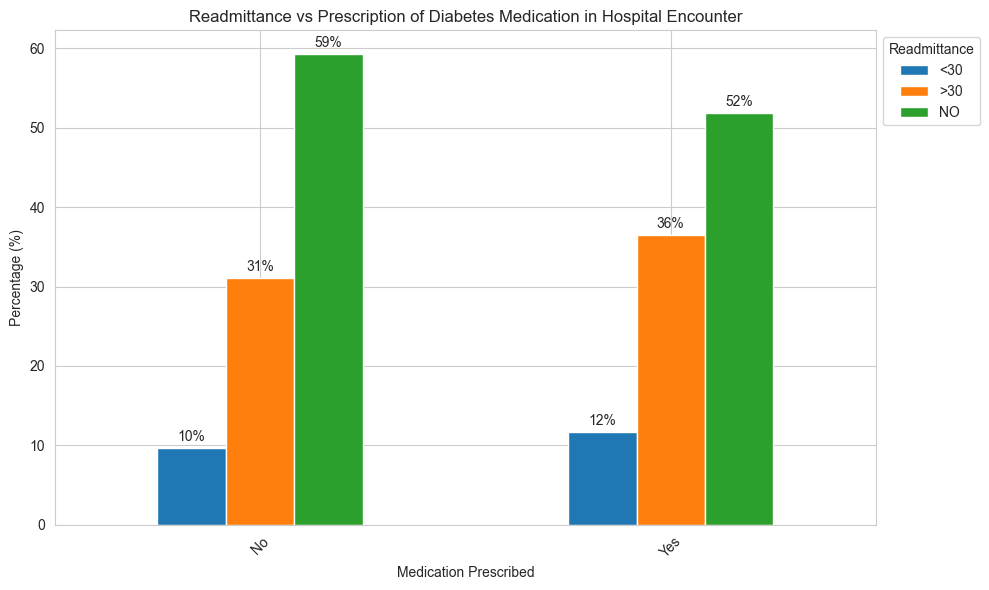

In [26]:
cross = pd.crosstab(clean_hospital_data_df["diabetesMed"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(10, 6))

med_prescribed_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in med_prescribed_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    med_prescribed_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs Prescription of Diabetes Medication in Hospital Encounter")
ax.set_xlabel("Medication Prescribed")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

From the above plot, we can see:

* There is a slight difference in the readmittance rates for patients who had diabetes medication prescribed during their hospital encounter as opposed to not. The rates are 48% & 41% respectively.
* This shows a 7% difference.
* This could be due to the fact that the issue causing the patients most problems was not diabetes and therefore other medication was required to be prescribed.
* It also could be that the medication prescribed was not fitting well with the patient and different medication was required to be prescribed.

For the analysis of all the medications/medication-pairs that patients were taking, it is first important for us to create a temporary dataframe with only the required columns.

In [27]:
temp_cols = ["readmitted", "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", 
             "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", 
             "acarbose", "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", 
             "glyburide-metformin", "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", 
             "metformin-pioglitazone" ]

temp_df = clean_hospital_data_df[temp_cols]

Once this dataframe has been created, another temporary dataframe is required to be created that will be "Melted". Melting is the process in which a dataframe is changed from wide to long format. This will allow all the medications to become columns in the dataframe and then create their status (Up, down, stady, no change) as the values. This will allow us to easily visualise each medication and see if changes to those medications had any direct relation to readmittance rates in the patients.

In [28]:
med_df= temp_df.melt(id_vars="readmitted", value_vars= ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", 
             "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", 
             "acarbose", "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", 
             "glyburide-metformin", "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", 
             "metformin-pioglitazone" ], var_name="medication",value_name="status")

Next, a facetgrid of countplots was built to visualise and analyse this data. The countplots are horizontal as opposed to vertical. This was chosen because there are an odd number of plots and so the x axis was not clearly being seen.

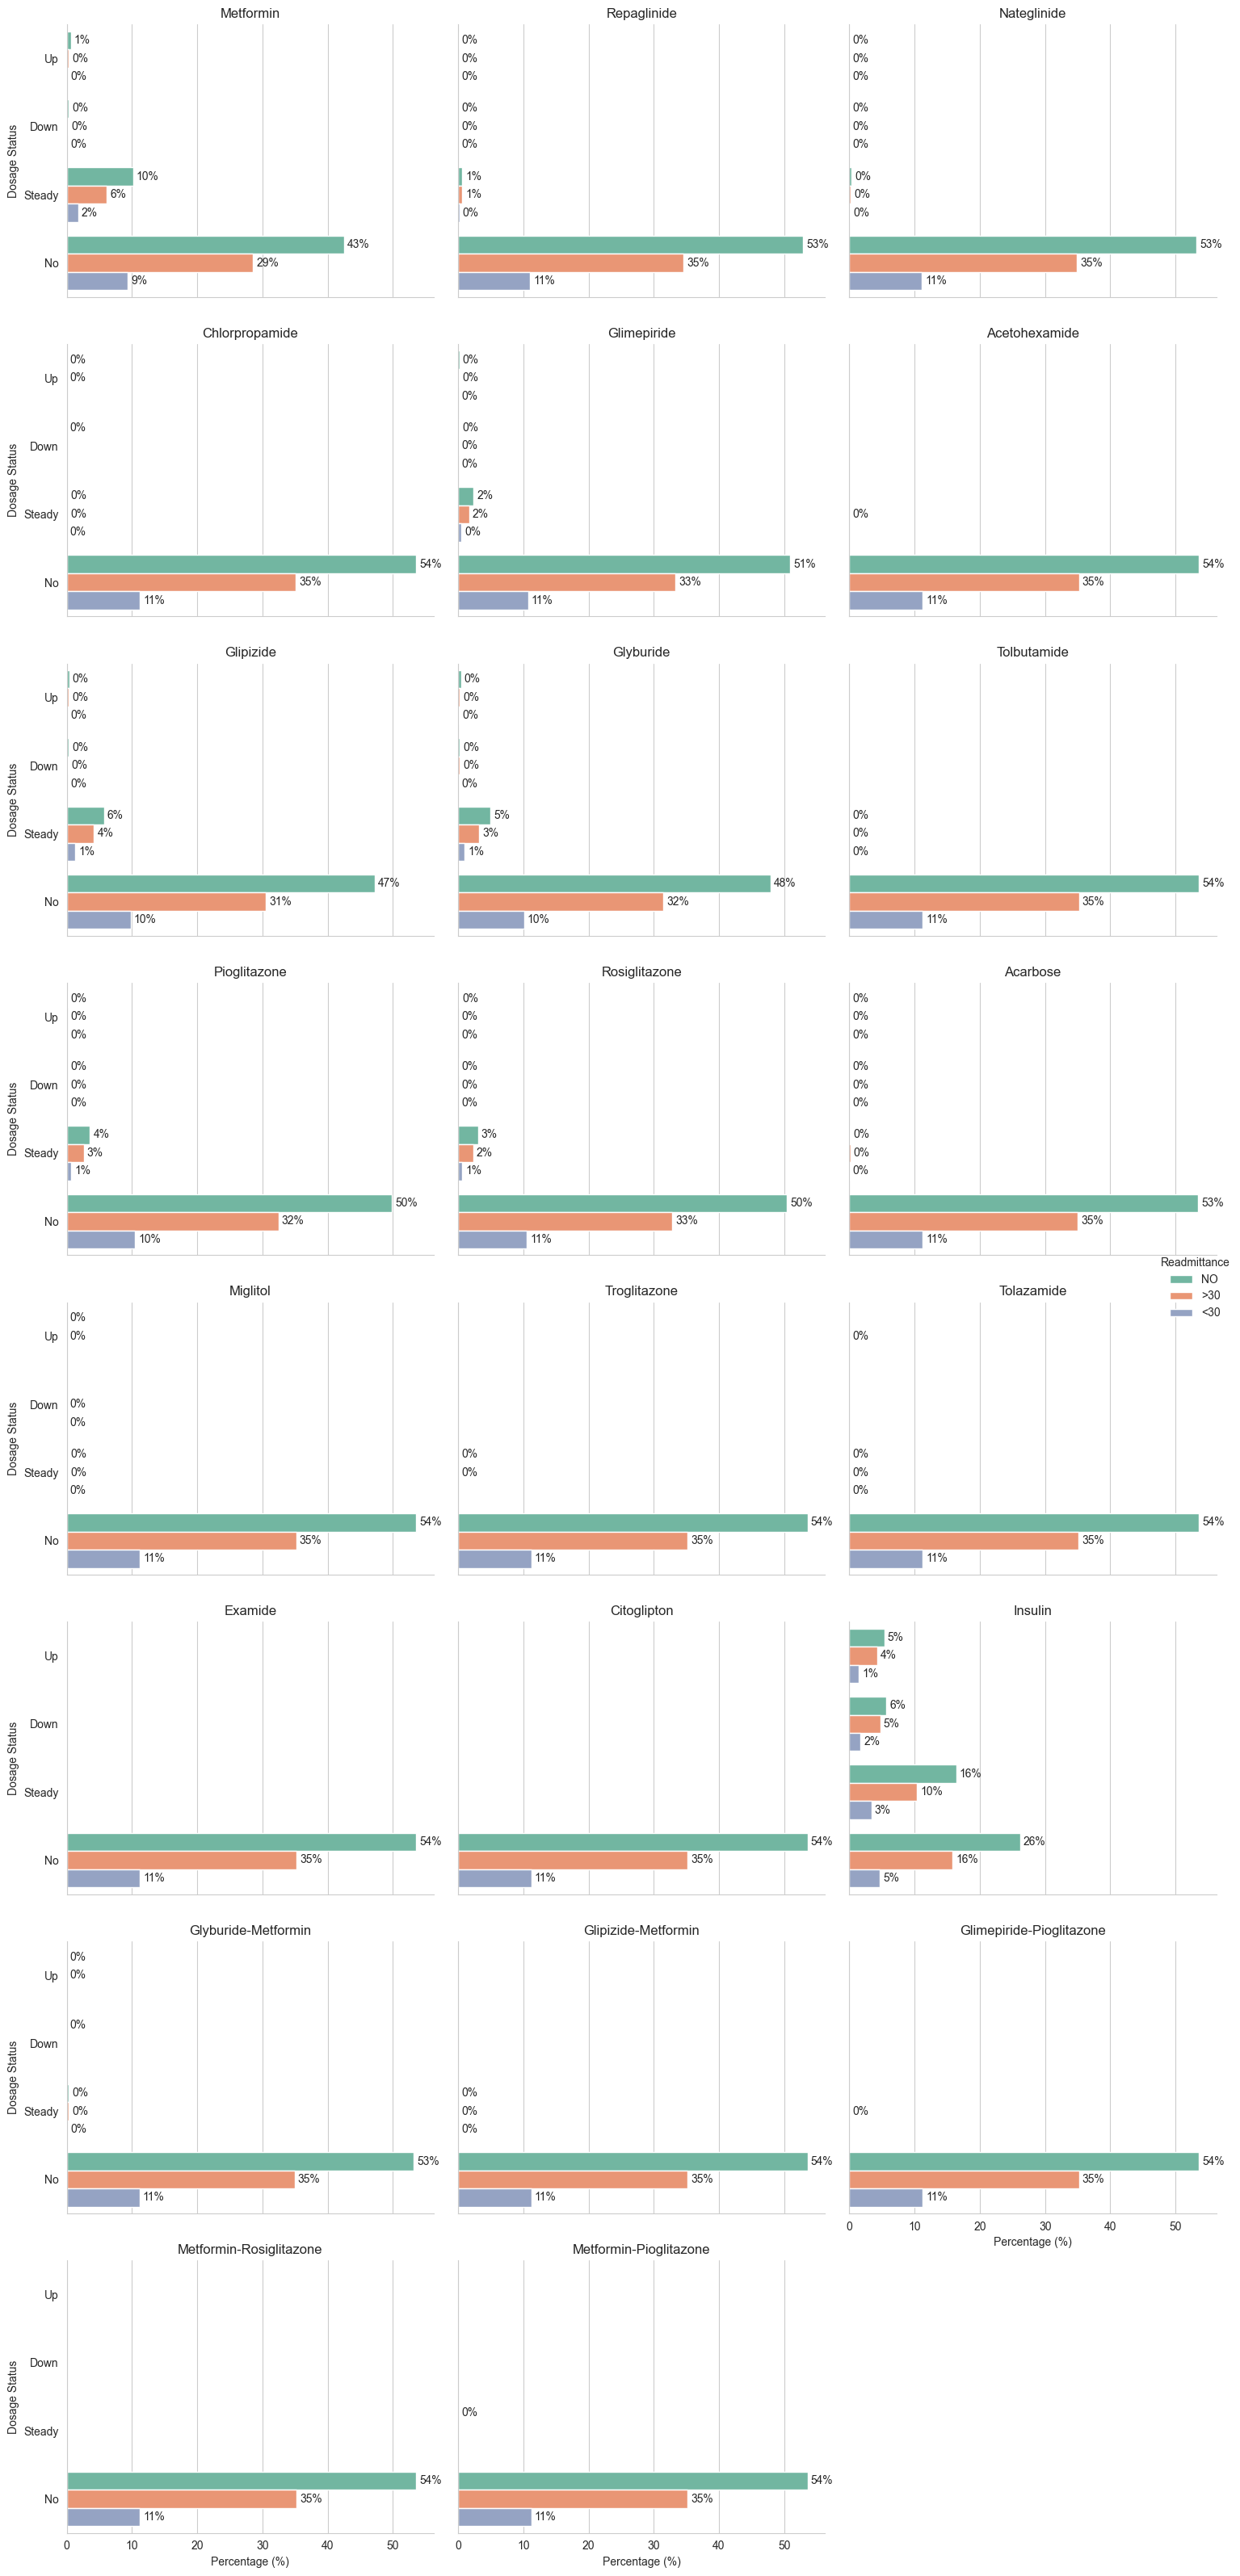

In [29]:
med_facet_grid = sns.FacetGrid(med_df, col="medication", col_wrap=3, height=4, aspect=1.2)
med_facet_grid.map_dataframe(
    sns.countplot,
    y="status",
    hue="readmitted",
    stat = "percent",
    order=["Up", "Down", "Steady", "No"],
    hue_order=["NO", ">30", "<30"],
    palette='Set2'
)

for ax in med_facet_grid.axes.flat:
    for container in ax.containers:
        labels = [f"{v.get_width():.0f}%" for v in container]
        ax.bar_label(container, labels=labels, padding=3)


med_facet_grid.add_legend(title='Readmittance')
med_facet_grid.set_titles(col_template='{col_name}')

for ax in med_facet_grid.axes.flat:
    ax.set_title(ax.get_title().title())

med_facet_grid.set_axis_labels('Percentage (%)', 'Dosage Status')


plt.tight_layout()
plt.show()


Analysis

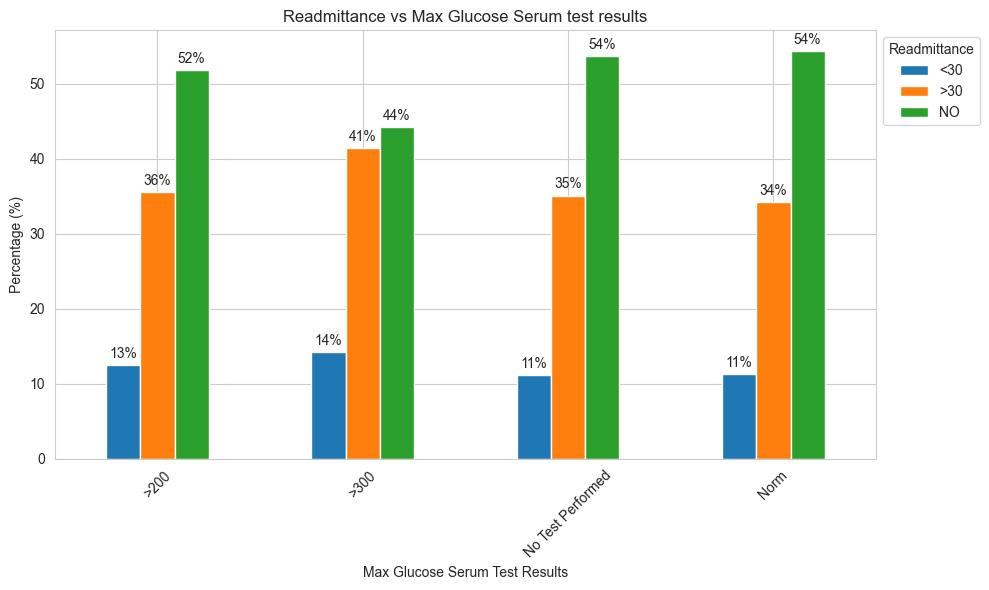

In [31]:
cross = pd.crosstab(clean_hospital_data_df["max_glu_serum"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(10, 6))

med_prescribed_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in med_prescribed_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    med_prescribed_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs Max Glucose Serum test results")
ax.set_xlabel("Max Glucose Serum Test Results")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

From the above plot, we can see:

* The readmittance rates for the different categories are as follows:
    * (Measurement)>200 - 49%
    * (Measurement)>300 - 55%
    * No test performed - 46%
    * Normal - 45%
* It shows that patients where the reading was >300 were 10% more likely to be readmitted to hospital.

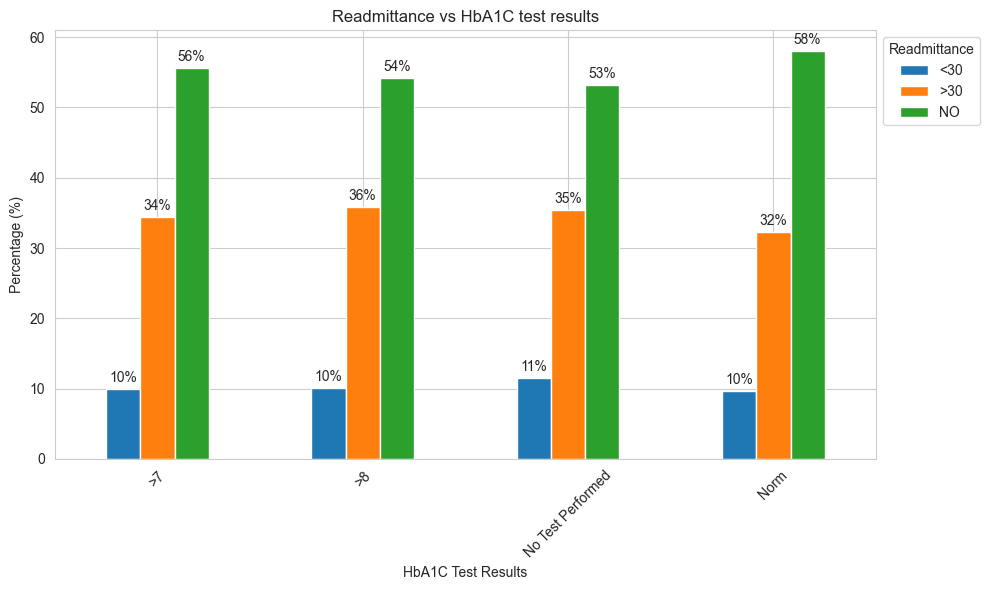

In [34]:
cross = pd.crosstab(clean_hospital_data_df["A1Cresult"], clean_hospital_data_df["readmitted"], normalize= "index")*100

fig, ax = plt.subplots(figsize=(10, 6))

med_prescribed_cross_plot = cross.plot(kind="bar", ax=ax, edgecolor="white")


for container in med_prescribed_cross_plot.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    med_prescribed_cross_plot.bar_label(container, labels=labels, padding= 3)


ax.set_title("Readmittance vs HbA1C test results")
ax.set_xlabel("HbA1C Test Results")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Readmittance", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

From the above plot, we can see:

* The readmittance rates for the different categories are as follows:
    * (Measurement)>7 - 44%
    * (Measurement)>8 - 46%
    * No test performed - 46%
    * Normal - 42%
* It shows that patients who had no test performed were equally as likely to be readmitted to hospital as those who's measurements were >8.
* This is important to note as it identifies the importance of testing patients.
* This is further established by the fact that patients who had no test performed had the highest readmittance rates in less than 30 days from their hospital encounter (11%). This indicates that the missed test has some relation to readmission rates.

---

# Conclusions

Conclusions derived against the hypotheses are as follows:

1) Age: 
    * H<sub>0</sub>: Age has no impact on diabetes patient readmittance rates to hospital.
2) Race:
    * H<sub>0</sub>: Race has no impact on diabetes patient readmittance rates to hospital.
3) Gender:
    * H<sub>0</sub>: Gender has no impact on diabetes patient readmittance rates to hospital.
4) Time in hospital:
    * H<sub>0</sub>: Time spent in hospital during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
5) Number of medications:
    * H<sub>0</sub>: Number of medications administered during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
6) Number of Lab procedures:
    * H<sub>0</sub>: Number of lab procedures performed during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
7) Number of Non-lab procedures:
    * H<sub>0</sub>: Number of non-lab procedures performedduring a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
8) Prior Visit History:
    * H<sub>0</sub>: The type of prior visits a patient does (Inpatient, Outpatient, Emergency) over the last year, has no impact on diabetes patient readmittance rates to hospital.
9) Diagnosis type:
    * H<sub>0</sub>: The type of diagnoses during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
10) Medicinal Changes:
    * H<sub>0</sub>: Any Medicinal changes during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.
11) Testing performed:
    * H<sub>0</sub>: Blood testing performed during a patient's latest encounter, has no impact on diabetes patient readmittance rates to hospital.

---

# Evaluation and Ethical Considerations